In [1]:
print("Hello Vaishnavi")


Hello Vaishnavi


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

print("Dataset Loaded Successfully")


Dataset Loaded Successfully


In [4]:
print(iris)


{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [5]:
print("Shape of Dataset:", iris.data.shape)


Shape of Dataset: (150, 4)


In [6]:
print(iris.feature_names)


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
print(iris.target_names)


['setosa' 'versicolor' 'virginica']


In [8]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["Species"] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df.isnull().sum()


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

In [10]:
df.dtypes


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species                int64
dtype: object

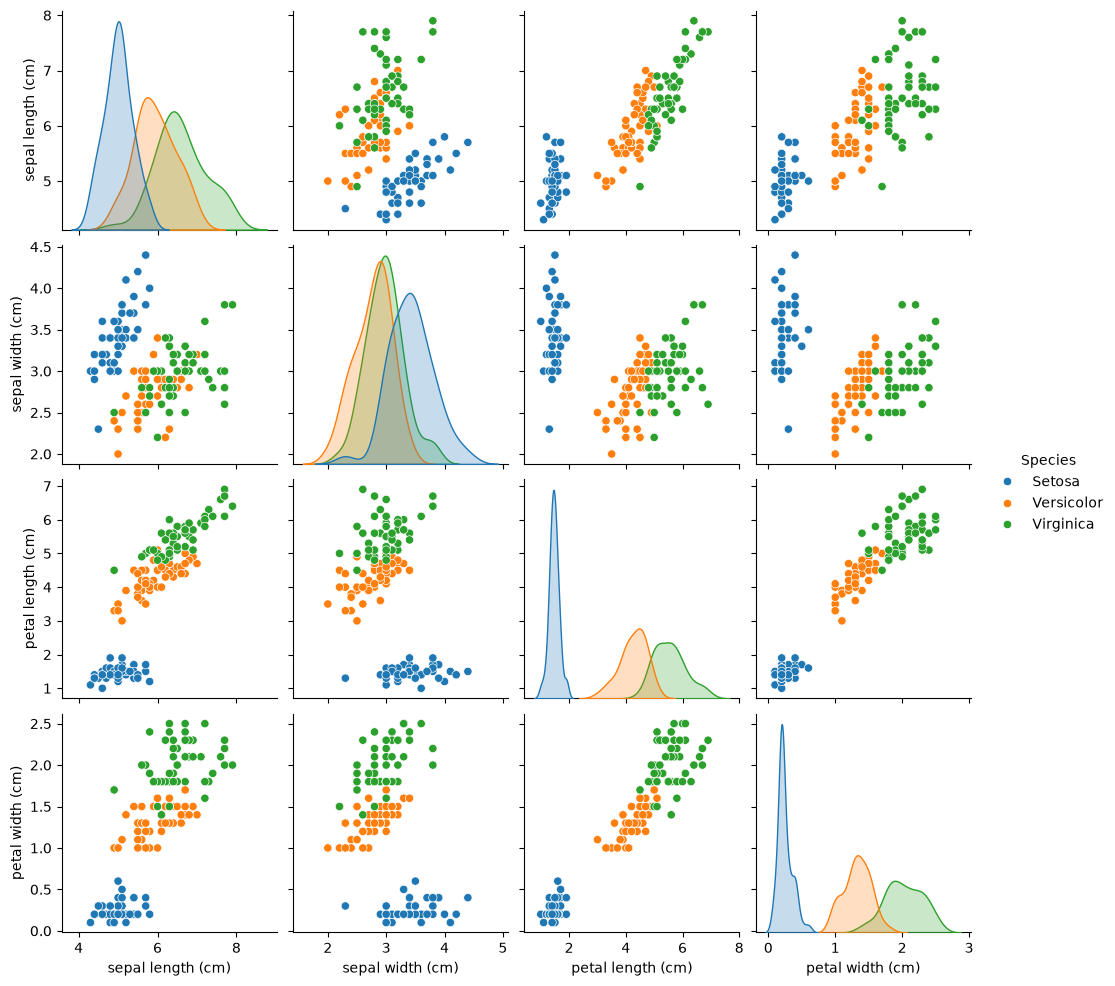

In [11]:
df["Species"] = df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

sns.pairplot(df, hue="Species")
plt.show()


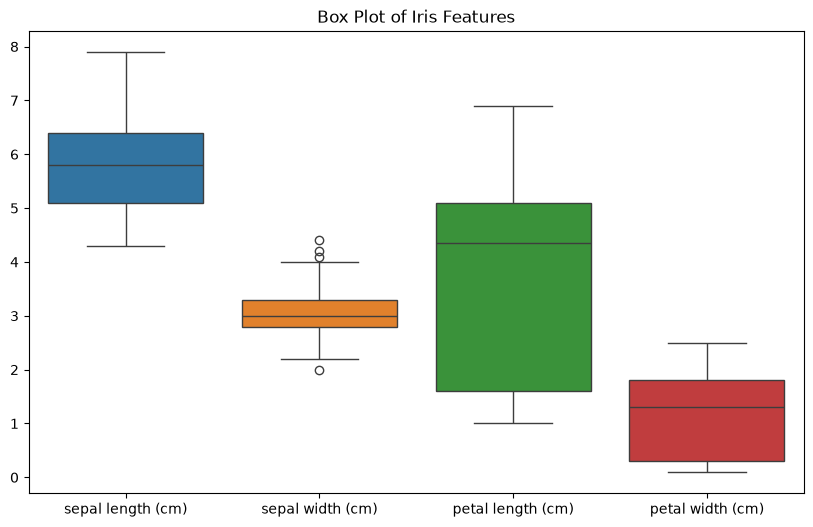

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:,0:4])
plt.title("Box Plot of Iris Features")
plt.show()


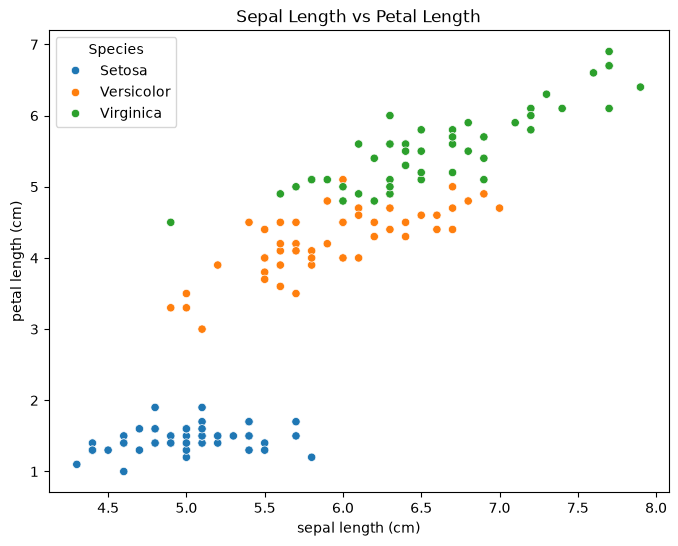

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="Species",
    data=df
)

plt.title("Sepal Length vs Petal Length")
plt.show()


In [14]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (120, 4)
Testing Data: (30, 4)


In [15]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=200)

model1.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")


Logistic Regression Model Trained Successfully


In [16]:
y_pred1 = model1.predict(X_test)

print(y_pred1)


[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [17]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test, y_pred1)

print("Logistic Regression Accuracy:", accuracy1)


Logistic Regression Accuracy: 1.0


In [18]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(random_state=42)

model2.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")


Random Forest Model Trained Successfully


In [19]:
y_pred2 = model2.predict(X_test)

print(y_pred2)


[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [20]:
accuracy2 = accuracy_score(y_test, y_pred2)

print("Random Forest Accuracy:", accuracy2)


Random Forest Accuracy: 1.0


In [21]:
print("Logistic Regression Accuracy :", accuracy1)
print("Random Forest Accuracy       :", accuracy2)

if accuracy1 > accuracy2:
    print("Best Model: Logistic Regression")
elif accuracy2 > accuracy1:
    print("Best Model: Random Forest")
else:
    print("Both Models Performed Equally Well")
    

Logistic Regression Accuracy : 1.0
Random Forest Accuracy       : 1.0
Both Models Performed Equally Well


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred1)

print(cm)


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


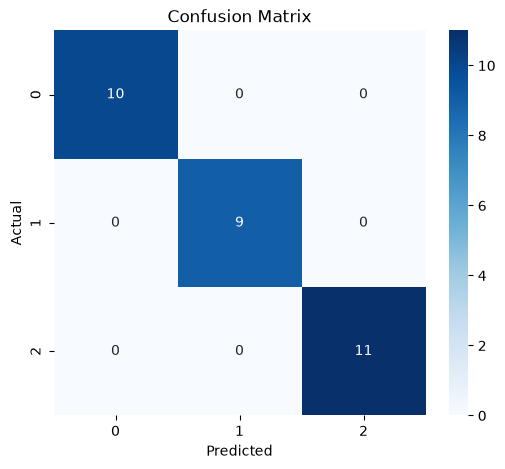

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred1))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [25]:
cm2 = confusion_matrix(y_test, y_pred2)

print(cm2)


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [26]:
print(classification_report(y_test, y_pred2))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [27]:
print("========== FINAL RESULT ==========")
print()

print("Logistic Regression Accuracy :", accuracy1)

print("Random Forest Accuracy       :", accuracy2)

print()

if accuracy1 > accuracy2:
    print("Best Model : Logistic Regression")

elif accuracy2 > accuracy1:
    print("Best Model : Random Forest")

else:
    print("Both Models Performed Equally Well")
    

========== FINAL RESULT ==========

Logistic Regression Accuracy : 1.0
Random Forest Accuracy       : 1.0

Both Models Performed Equally Well


# Conclusion

The Iris Flower Classification project was successfully completed.

Two machine learning models were trained:

- Logistic Regression
- Random Forest

Both models achieved high accuracy.

After comparing the results, the best-performing model was selected based on accuracy.

This project demonstrates how machine learning can classify Iris flowers using four flower measurements.
